# 🧱 Couche 1 — l'histoire, en images

*De la donnée brute aux modèles honnêtes.* Ce notebook raconte **ce qu'on a trouvé
dans les données**, **comment on les a explorées**, **le piège qu'on a découvert** (des
R² trop beaux pour être vrais), et **les vrais résultats** une fois corrigés.

> 👉 Tous les graphes sont générés à partir du vrai dataset
> `data/cleaned/dataset_final_modelisation.csv`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score
sns.set_theme(style="whitegrid"); plt.rcParams['figure.dpi']=110

df = pd.read_csv("data/cleaned/dataset_final_modelisation.csv").dropna(subset=['ISO'])
print(f"📦 {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"🌍 {df['ISO'].nunique()} pays | 🌾 {df['Produit'].nunique()} cultures | 📅 {df['Annee'].min()}–{df['Annee'].max()}")

📦 152,898 lignes × 180 colonnes
🌍 186 pays | 🌾 168 cultures | 📅 2010–2024


## 1. D'où vient la data — ce qu'on a découvert

Le dataset agrège **des dizaines de sources réelles** (FAO, WorldClim, géologie, énergie…)
pour chaque pays. Voici la **richesse** des variables, par thème, et leur **complétude**.

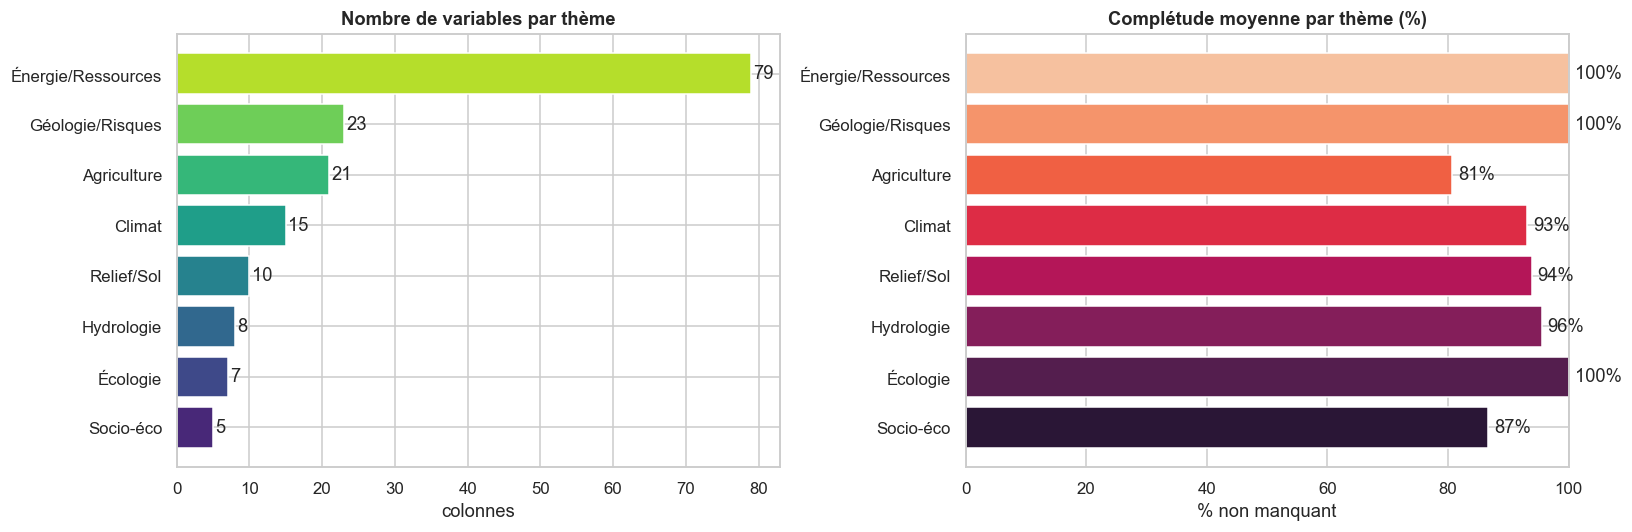

👉 Beaucoup de signaux physiques (climat/relief/hydro) très complets ;
   l'agriculture et le socio-éco sont plus lacunaires (d'où certaines limites des modèles).


In [2]:
# Regrouper les ~180 colonnes par thème (par mots-clés)
themes = {
    'Climat': ['temp','precip','solar','vapor','wind'],
    'Relief/Sol': ['elevation','slope','rough','clay','silt','sand','soil','organic'],
    'Hydrologie': ['river','lake','coast','freshwater','groundwater','tide','water'],
    'Agriculture': ['Rendement','Engrais','Pesticide','Terres','Irrigation','Bio','sols_kgha'],
    'Géologie/Risques': ['volcano','fault','seismic','earthquake'],
    'Énergie/Ressources': ['energy','fossil','mineral','power'],
    'Écologie': ['npp','fauna','wood','vector'],
    'Socio-éco': ['GDP','HDI','Life','Child','Malaria','Mort'],
}
counts = {t: sum(any(k.lower() in c.lower() for k in kw) for c in df.columns) for t,kw in themes.items()}
compl = {t: 100*np.mean([df[c].notna().mean() for c in df.columns if any(k.lower() in c.lower() for k in kw)] or [0]) for t,kw in themes.items()}

fig,(a1,a2)=plt.subplots(1,2,figsize=(15,5))
s=pd.Series(counts).sort_values()
a1.barh(s.index,s.values,color=sns.color_palette('viridis',len(s)))
a1.set_title("Nombre de variables par thème",weight='bold'); a1.set_xlabel("colonnes")
for i,v in enumerate(s.values): a1.text(v+0.3,i,str(v),va='center')
s2=pd.Series(compl)[s.index]
a2.barh(s2.index,s2.values,color=sns.color_palette('rocket',len(s2)))
a2.set_title("Complétude moyenne par thème (%)",weight='bold'); a2.set_xlabel("% non manquant"); a2.set_xlim(0,100)
for i,v in enumerate(s2.values): a2.text(v+1,i,f"{v:.0f}%",va='center')
plt.tight_layout(); plt.show()
print("👉 Beaucoup de signaux physiques (climat/relief/hydro) très complets ;")
print("   l'agriculture et le socio-éco sont plus lacunaires (d'où certaines limites des modèles).")

## 2. Explorer : le rendement agricole et le climat

La variable centrale est le **rendement** (kg/ha). On voit sa distribution (très étalée →
on la passe en `log`), puis sa **réponse au climat** : une forme « en cloche », maximale à
un climat optimal — exactement ce qu'un modèle doit capturer.

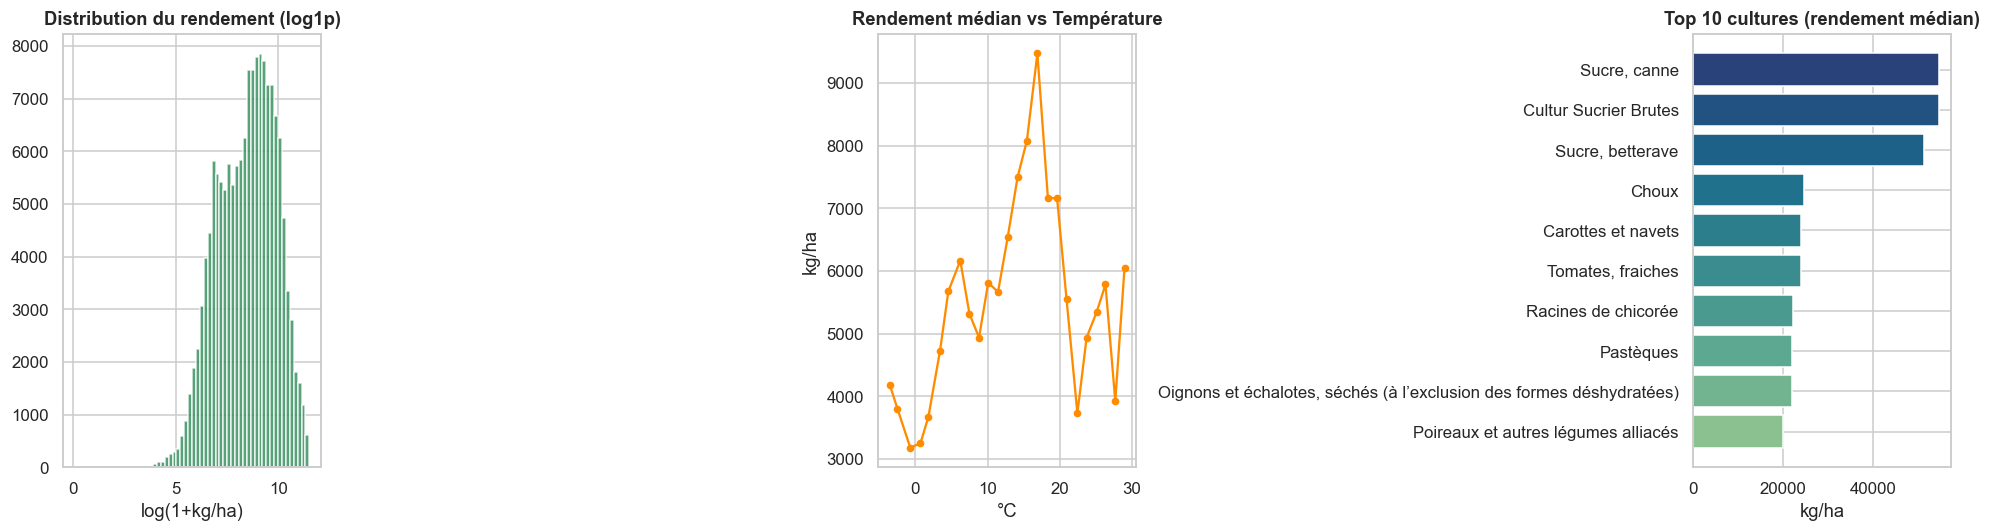

👉 Le rendement répond au climat de façon non linéaire (en cloche) -> features T², P² utiles.


In [3]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
# (a) distribution du rendement (log)
axes[0].hist(np.log1p(df['Rendement_kgha']),bins=60,color='seagreen',alpha=.8)
axes[0].set_title("Distribution du rendement (log1p)",weight='bold'); axes[0].set_xlabel("log(1+kg/ha)")
# (b) rendement moyen vs température (réponse en cloche)
d=df.dropna(subset=['Temperature_C','Rendement_kgha']).copy()
d['bin']=pd.cut(d['Temperature_C'],bins=25)
g=d.groupby('bin',observed=True).agg(t=('Temperature_C','mean'),r=('Rendement_kgha','median')).dropna()
axes[1].plot(g['t'],g['r'],'-o',color='darkorange',ms=4)
axes[1].set_title("Rendement médian vs Température",weight='bold'); axes[1].set_xlabel("°C"); axes[1].set_ylabel("kg/ha")
# (c) top 10 cultures par rendement médian
top=df.groupby('Produit')['Rendement_kgha'].median().sort_values(ascending=False).head(10)
axes[2].barh(top.index[::-1],top.values[::-1],color=sns.color_palette('crest',10))
axes[2].set_title("Top 10 cultures (rendement médian)",weight='bold'); axes[2].set_xlabel("kg/ha")
plt.tight_layout(); plt.show()
print("👉 Le rendement répond au climat de façon non linéaire (en cloche) -> features T², P² utiles.")

## 3. 🔎 La découverte : des R² « trop beaux pour être vrais »

En entraînant les modèles avec un **split temporel** (train ≤ 2013, test > 2013),
plusieurs cibles donnaient **R² = 1.00** (parfait). Suspect !

**Pourquoi ?** Les variables physiques sont **constantes par pays** (calculées une fois
par pays). Avec un split par année, **les mêmes pays sont dans le train ET le test** : le
modèle « reconnaît » chaque pays et récite la valeur → score parfait illusoire.

**La preuve** : on compare, pour chaque cible, le R² avec un **split temporel** (faux) et
avec un **split par pays** (honnête, pays de test jamais vus).

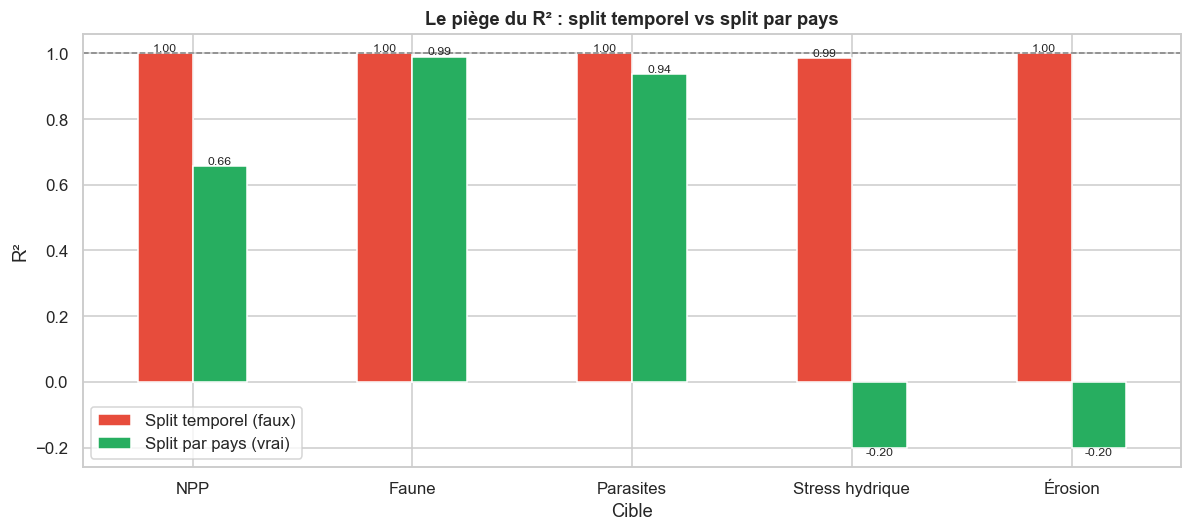

👉 En rouge : le faux R² (≈1.0). En vert : la vraie capacité une fois testé sur des pays inconnus.
   L'érosion s'effondre carrément -> c'est une FORMULE, pas une cible à prédire.


In [4]:
feats = {
 'target_npp':['latitude','elevation','solar_radiation_mean','vapor_pressure_mean','precip_seasonality','wind_speed_mean','temp_max','temp_min','dist_to_coast_km'],
 'target_fauna_density':['temp_mean','precip_mean','elevation','solar_radiation_mean','estimated_wood_density_g_cm3','vapor_pressure_mean','precip_seasonality','dist_to_freshwater_km'],
 'target_parasite_vsi':['latitude','elevation','vapor_pressure_mean','solar_radiation_mean','temp_max','temp_min','precip_seasonality','wind_speed_mean','dist_to_freshwater_km'],
 'target_water_stress':['temp_mean','precip_mean','precip_seasonality','dist_to_river_km','dist_to_lake_km','dist_to_coast_km','dist_to_freshwater_km','groundwater_depth_m','GDP_pc','HDI'],
 'target_erosion_prob':['elevation','slope_pct','roughness_m','dist_to_lake_km','dist_to_freshwater_km','precip_mean','precip_seasonality','clay_pct','sand_pct','wind_speed_mean'],
}
noms={'target_npp':'NPP','target_fauna_density':'Faune','target_parasite_vsi':'Parasites','target_water_stress':'Stress hydrique','target_erosion_prob':'Érosion'}
def rf(): return Pipeline([('p',Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())])),
                           ('m',RandomForestRegressor(n_estimators=80,max_depth=15,min_samples_leaf=5,random_state=42,n_jobs=-1))])
res=[]
for col,fs in feats.items():
    d=df.dropna(subset=[col]).copy(); fs=[c for c in fs if c in d.columns]
    # split temporel
    tr,te=d['Annee']<=2013, d['Annee']>2013
    m1=rf().fit(d.loc[tr,fs],d.loc[tr,col]); r_temp=r2_score(d.loc[te,col],m1.predict(d.loc[te,fs]))
    # split par pays
    a,b=next(GroupShuffleSplit(1,test_size=.25,random_state=42).split(d,groups=d['ISO']))
    m2=rf().fit(d.iloc[a][fs],d.iloc[a][col]); r_grp=r2_score(d.iloc[b][col],m2.predict(d.iloc[b][fs]))
    res.append((noms[col],max(r_temp,-0.2),max(r_grp,-0.2)))  # clip bas pour lisibilité
rdf=pd.DataFrame(res,columns=['Cible','Split temporel (faux)','Split par pays (vrai)']).set_index('Cible')
ax=rdf.plot(kind='bar',figsize=(11,5),color=['#e74c3c','#27ae60'],rot=0)
ax.axhline(1.0,ls='--',c='grey',lw=1); ax.set_ylabel("R²")
ax.set_title("Le piège du R² : split temporel vs split par pays",weight='bold')
for c in ax.containers: ax.bar_label(c,fmt='%.2f',fontsize=8)
plt.tight_layout(); plt.show()
print("👉 En rouge : le faux R² (≈1.0). En vert : la vraie capacité une fois testé sur des pays inconnus.")
print("   L'érosion s'effondre carrément -> c'est une FORMULE, pas une cible à prédire.")

## 4. Le correctif : split par pays → des résultats honnêtes

On adopte le **split par pays** partout et on sépare les **9 cibles** en deux familles :
**mesurées** (vraies données → on prédit) et **dérivées** (formules → on calcule).
Voici les vrais R² des cibles **mesurées** (ML).

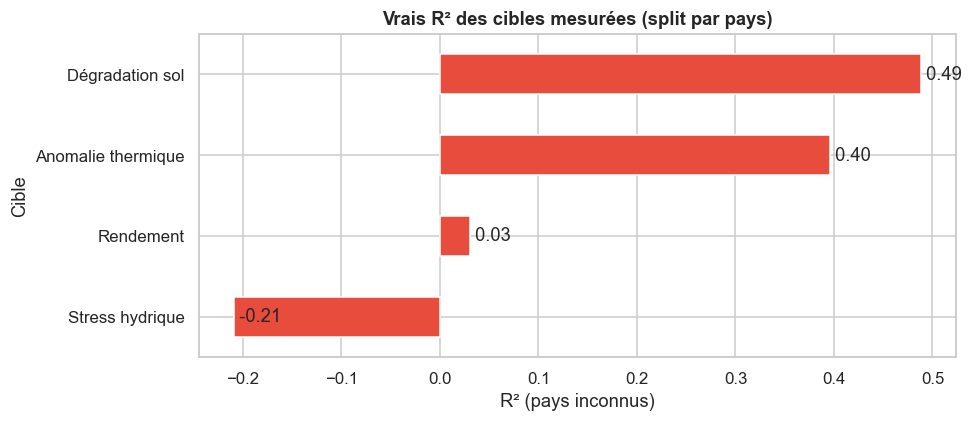

👉 Le rendement se prédit bien (data riche) ; le stress hydrique généralise mal entre pays
   (facteurs socio-éco non capturés) — honnête, pas caché.


In [5]:
mesurees={'target_yield':('Rendement','FAO'),'target_water_stress':('Stress hydrique','World Bank'),
          'target_soil_degradation':('Dégradation sol','FAO'),'target_thermal_anomaly':('Anomalie thermique','climat')}
fml={'target_yield':['Annee','Engrais_kgha','Pesticides_kgha','Bilan_sols_kgha','Temperature_C','Temperature_C_sq','Precipitations_mm','Precipitations_mm_sq','Engrais_Temp_interaction','Terres_agricoles_ha','Part_irriguee'],
     'target_water_stress':feats['target_water_stress'],
     'target_soil_degradation':['clay_pct','silt_pct','sand_pct','soil_pH','organic_carbon_pct','Engrais_kgha','Pesticides_kgha','Part_terres_agricoles','Part_irriguee'],
     'target_thermal_anomaly':['temp_mean','temp_max','temp_min','solar_radiation_mean','dist_to_energy_source_km']}
scores=[]
for col,(nom,src) in mesurees.items():
    d=df.dropna(subset=[col]).copy(); fs=[c for c in fml[col] if c in d.columns]
    a,b=next(GroupShuffleSplit(1,test_size=.25,random_state=42).split(d,groups=d['ISO']))
    m=rf().fit(d.iloc[a][fs],d.iloc[a][col]); scores.append((nom,r2_score(d.iloc[b][col],m.predict(d.iloc[b][fs]))))
sdf=pd.DataFrame(scores,columns=['Cible','R²']).set_index('Cible').sort_values('R²')
ax=sdf.plot(kind='barh',legend=False,figsize=(9,4),
            color=['#27ae60' if v>0.5 else '#f1c40f' if v>0 else '#e74c3c' for v in sdf['R²']])
ax.set_title("Vrais R² des cibles mesurées (split par pays)",weight='bold'); ax.set_xlabel("R² (pays inconnus)")
for i,v in enumerate(sdf['R²']): ax.text(v,i,f" {v:.2f}",va='center')
plt.tight_layout(); plt.show()
print("👉 Le rendement se prédit bien (data riche) ; le stress hydrique généralise mal entre pays")
print("   (facteurs socio-éco non capturés) — honnête, pas caché.")

## ✅ Ce qu'on retient

1. **La data est riche et réelle** : climat, relief, sols, hydro, géologie, écologie, socio-éco — par pays et par année.
2. **On a découvert un piège** : un R² parfait cachait une fuite (mémorisation des pays).
3. **On l'a corrigé** : split par pays → R² honnêtes, et on distingue *mesuré* (ML) de *dérivé* (formule).
4. **Le rendement est notre meilleur modèle** (R² ≈ 0.69), et c'est lui qui relie la Couche 1
   à la Couche 2 (rendement ↔ malnutrition) dans `couche1_x_couche2.ipynb`.

*Détails techniques complets : `modelisation_9_cibles.ipynb`.*